In [1]:
import pandas as pd

info = pd.read_csv("information.csv")
occupancy = pd.read_csv("occupancy.csv")
duration = pd.read_csv("duration.csv")
volume = pd.read_csv("volume.csv")
price = pd.read_csv("price.csv")
time_df = pd.read_csv("time.csv")

In [2]:
for name, df in {
    "info": info,
    "occupancy": occupancy,
    "duration": duration,
    "volume": volume,
    "price": price,
    "time": time_df
}.items():

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print(df.shape)
    print(df.head())



info
(247, 10)
   num  grid  count  fast_count  slow_count  area       lon        la  CBD  \
0    1   102     30           3          27  0.71  114.1030  22.54041    0   
1    3   105     93           0          93  0.77  114.1208  22.55127    0   
2    5   107     88           2          86  0.89  114.1304  22.54486    0   
3    6   108     39           0          39  1.26  114.1315  22.55403    0   
4    7   109     39           0          39  3.15  114.1430  22.56388    0   

   dynamic_pricing  
0                0  
1                0  
2                0  
3                0  
4                0  


occupancy
(8640, 248)
   timestamp  102  105  107  108  109  110  111  115  123  ...  1160  1162  \
0          1   12   16   24   15    6    8   24    1    2  ...     0    12   
1          2   12   16   24   15    6    8   24    1    2  ...     0    12   
2          3   12   16   24   15    6    8   24    1    2  ...     0    12   
3          4   12   16   24   15    6    8   24    1

In [4]:
info = pd.read_csv("information.csv")
time_df = pd.read_csv("time.csv")

print(info.shape)
print(info.columns)
display(info.head())

print(time_df.shape)
print(time_df.columns)
display(time_df.head())

(247, 10)
Index(['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la',
       'CBD', 'dynamic_pricing'],
      dtype='object')


,num,grid,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,102,30,3,27,0.71,114.1030,22.54041,0,0
1,3,105,93,0,93,0.77,114.1208,22.55127,0,0
2,5,107,88,2,86,0.89,114.1304,22.54486,0,0
3,6,108,39,0,39,1.26,114.1315,22.55403,0,0
4,7,109,39,0,39,3.15,114.1430,22.56388,0,0


(8640, 6)
Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')


,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0


In [5]:
volume = pd.read_csv("volume.csv")

print(volume.shape)
display(volume.head())

(8640, 248)


,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,...,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
1,2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
2,3,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
3,4,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,426.641667,8.166667,0.583333,3.500000,3.208333
4,5,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,452.708333,8.166667,0.583333,3.500000,3.208333


In [6]:
# Create Timestamp

time_df['timestamp'] = pd.to_datetime(
    time_df[
        ['year','month','day','hour','minute','second']
    ]
)

time_df.head()

,month,day,year,hour,minute,second,timestamp
0,6,19,2022,0,0,0,2022-06-19 00:00:00
1,6,19,2022,0,5,0,2022-06-19 00:05:00
2,6,19,2022,0,10,0,2022-06-19 00:10:00
3,6,19,2022,0,15,0,2022-06-19 00:15:00
4,6,19,2022,0,20,0,2022-06-19 00:20:00


In [7]:
def reshape_metric(df, value_name):

    long_df = df.melt(
        id_vars='timestamp',
        var_name='station_id',
        value_name=value_name
    )

    long_df['station_id'] = (
        long_df['station_id']
        .astype(int)
    )

    return long_df

In [8]:
volume['timestamp'] = time_df['timestamp']

volume_long = reshape_metric(
    volume,
    'volume'
)

In [9]:
occupancy['timestamp'] = time_df['timestamp']

occupancy_long = reshape_metric(
    occupancy,
    'occupancy'
)

In [10]:
duration['timestamp'] = time_df['timestamp']

duration_long = reshape_metric(
    duration,
    'duration'
)

In [11]:
price['timestamp'] = time_df['timestamp']

price_long = reshape_metric(
    price,
    'price'
)

In [12]:
urbanev_master = (
    volume_long
    .merge(
        occupancy_long,
        on=['timestamp','station_id']
    )
    .merge(
        duration_long,
        on=['timestamp','station_id']
    )
    .merge(
        price_long,
        on=['timestamp','station_id']
    )
)

In [13]:
info = info.rename(
    columns={
        'grid':'station_id'
    }
)

In [14]:
urbanev_master = (
    urbanev_master
    .merge(
        info,
        on='station_id',
        how='left'
    )
)

In [15]:
print(urbanev_master.shape)

display(
    urbanev_master.head()
)

urbanev_master.isnull().sum().sort_values(
    ascending=False
).head(20)

(2134080, 15)


,timestamp,station_id,volume,occupancy,duration,price,num,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,2022-06-19 00:00:00,102,2.858333,12,0.49,0.924,1,30,3,27,0.71,114.103,22.54041,0,0
1,2022-06-19 00:05:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0
2,2022-06-19 00:10:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0
3,2022-06-19 00:15:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0
4,2022-06-19 00:20:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0


timestamp          0
station_id         0
volume             0
occupancy          0
duration           0
price              0
num                0
count              0
fast_count         0
slow_count         0
area               0
lon                0
la                 0
CBD                0
dynamic_pricing    0
dtype: int64

# The UrbanEV dataset captures charging activity across 247 stations over 30 days at 5-minute resolution, resulting in more than 2.1 million station-time observations.

# The UrbanEV datasets were originally distributed across multiple files containing charging volume, occupancy, duration, pricing, station metadata, and timestamp information. To facilitate downstream analysis, all datasets were aligned using timestamp and station identifiers and transformed into a unified analytical base.

The resulting dataset contains:

- 2,134,080 observations
- 247 charging stations
- 8,640 five-minute intervals
- No missing values after integration

# All charging demand, occupancy, duration, pricing, and station metadata were successfully integrated into a unified analytical base with zero missing values.

# Each record represents the operational state of a charging station at a specific point in time and contains charging demand, occupancy, duration, pricing, and station-level attributes.

In [16]:
# Charger Utilization Rate

urbanev_master['utilization_rate'] = (
    urbanev_master['occupancy']
    /
    urbanev_master['count']
)

In [18]:
# Revenue

urbanev_master['revenue'] = (
    urbanev_master['volume']
    *
    urbanev_master['price']
)

In [19]:
# Energy Cost per kWh

urbanev_master.rename(
    columns={
        'price':'energy_cost_per_kwh'
    },
    inplace=True
)

In [20]:
# Occupancy Density

urbanev_master['occupancy_density'] = (
    urbanev_master['occupancy']
    /
    urbanev_master['count']
)

In [21]:
# Queue Length Proxy

urbanev_master['queue_proxy'] = (
    urbanev_master['occupancy_density']
    *
    urbanev_master['volume']
)

In [22]:
urbanev_master.to_csv(
    'urbanev_master.csv',
    index=False
)

In [23]:
# Feature Engineering Validation

print(urbanev_master.shape)

urbanev_master[
    [
        'station_id',
        'volume',
        'occupancy',
        'count',
        'utilization_rate',
        'revenue',
        'occupancy_density',
        'queue_proxy'
    ]
].head()

(2134080, 19)


,station_id,volume,occupancy,count,utilization_rate,revenue,occupancy_density,queue_proxy
0,102,2.858333,12,30,0.4,2.6411,0.4,1.143333
1,102,4.375000,12,30,0.4,4.0425,0.4,1.750000
2,102,4.375000,12,30,0.4,4.0425,0.4,1.750000
3,102,4.375000,12,30,0.4,4.0425,0.4,1.750000
4,102,4.375000,12,30,0.4,4.0425,0.4,1.750000


In [25]:
print(urbanev_master.columns.tolist())

['timestamp', 'station_id', 'volume', 'occupancy', 'duration', 'energy_cost_per_kwh', 'num', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD', 'dynamic_pricing', 'utilization_rate', 'revenue', 'occupancy_density', 'queue_proxy']


In [27]:
feature_summary = (
    urbanev_master[
        [
            'volume',
            'occupancy',
            'duration',
            'energy_cost_per_kwh',
            'utilization_rate',
            'revenue',
            'occupancy_density',
            'queue_proxy'
        ]
    ]
    .describe()
)

display(feature_summary)

,volume,occupancy,duration,energy_cost_per_kwh,utilization_rate,revenue,occupancy_density,queue_proxy
count,2.134080e+06,2.134080e+06,2.134080e+06,2.134080e+06,2.134080e+06,2.134080e+06,2.134080e+06,2.134080e+06
mean,3.667845e+01,2.190204e+01,1.472631e+00,9.585707e-01,2.802482e-01,2.999742e+01,2.802482e-01,1.670270e+01
std,1.018935e+02,2.479975e+01,1.803075e+00,1.812571e-01,1.760547e-01,7.330484e+01,1.760547e-01,6.208912e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.333333e+00,5.000000e+00,3.333333e-01,8.495900e-01,1.515152e-01,2.275000e+00,1.515152e-01,3.938156e-01
50%,7.000000e+00,1.300000e+01,8.333333e-01,9.837500e-01,2.500000e-01,6.808958e+00,2.500000e-01,1.822917e+00
75%,2.333333e+01,3.000000e+01,1.862222e+00,1.072640e+00,3.779070e-01,2.170000e+01,3.779070e-01,7.534902e+00
max,1.492500e+03,2.200000e+02,1.708333e+01,1.470000e+00,1.076923e+00,1.026874e+03,1.076923e+00,1.318193e+03


In [28]:
urbanev_master[
    [
        'utilization_rate',
        'revenue',
        'occupancy_density',
        'queue_proxy'
    ]
].isnull().sum()

utilization_rate     0
revenue              0
occupancy_density    0
queue_proxy          0
dtype: int64

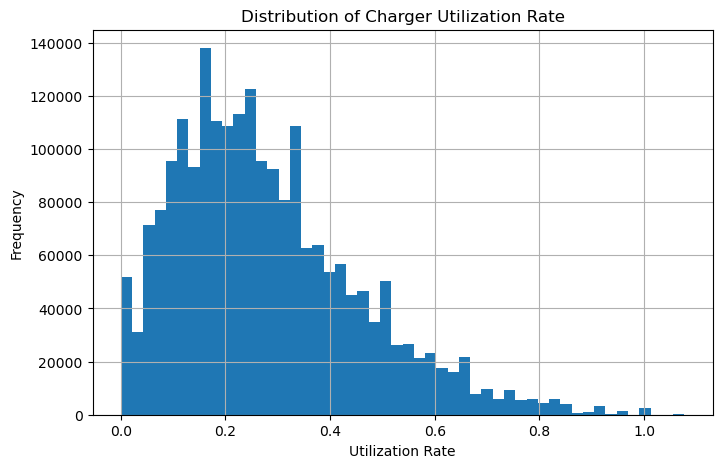

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

urbanev_master['utilization_rate'].hist(
    bins=50
)

plt.title(
    'Distribution of Charger Utilization Rate'
)

plt.xlabel('Utilization Rate')
plt.ylabel('Frequency')

plt.show()

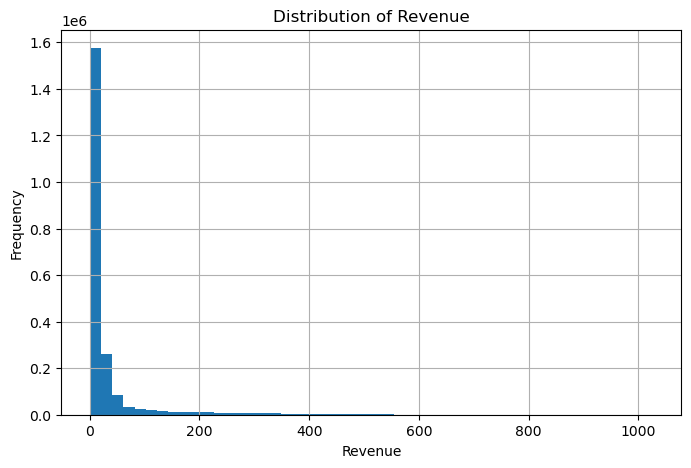

In [30]:
plt.figure(figsize=(8,5))

urbanev_master['revenue'].hist(
    bins=50
)

plt.title(
    'Distribution of Revenue'
)

plt.xlabel('Revenue')
plt.ylabel('Frequency')

plt.show()

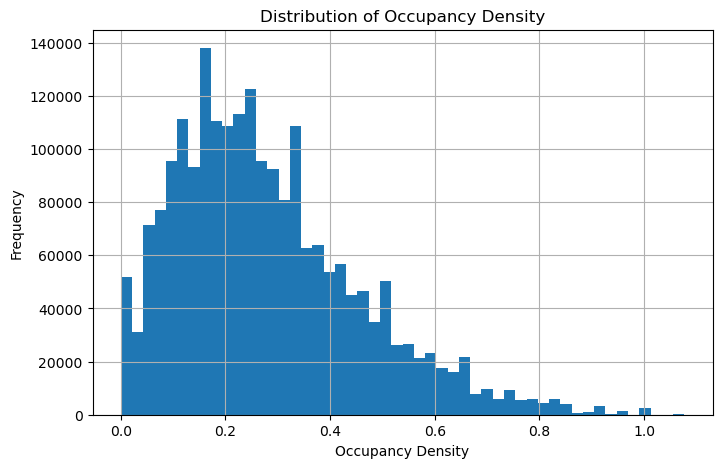

In [31]:
plt.figure(figsize=(8,5))

urbanev_master['occupancy_density'].hist(
    bins=50
)

plt.title(
    'Distribution of Occupancy Density'
)

plt.xlabel('Occupancy Density')
plt.ylabel('Frequency')

plt.show()

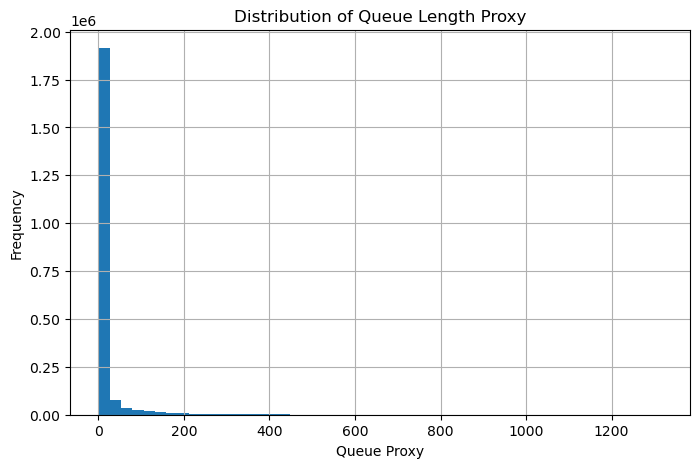

In [32]:
plt.figure(figsize=(8,5))

urbanev_master['queue_proxy'].hist(
    bins=50
)

plt.title(
    'Distribution of Queue Length Proxy'
)

plt.xlabel('Queue Proxy')
plt.ylabel('Frequency')

plt.show()

In [33]:
# Top Congested Stations

top_congested = (
    urbanev_master
    .groupby('station_id')
    ['occupancy_density']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_congested)

station_id
1029    0.760269
715     0.734580
570     0.639760
732     0.614578
982     0.589400
1131    0.582488
719     0.579707
835     0.576659
712     0.575697
991     0.561282
Name: occupancy_density, dtype: float64

# Revenue generation is highly concentrated among a small subset of stations, indicating that network demand is not evenly distributed.

In [50]:
# Congestion KPIs

station_occ = (
    urbanev_master
    .groupby('station_id')
    ['occupancy_density']
    .mean()
)

print(station_occ.describe())

count    247.000000
mean       0.280248
std        0.133285
min        0.061750
25%        0.174921
50%        0.274231
75%        0.361176
max        0.760269
Name: occupancy_density, dtype: float64


In [51]:
print(
    (station_occ > 0.7).sum()
)

2


# Although average network utilization remains moderate (28%), two stations consistently operate above 70% occupancy, indicating localized congestion hotspots.

In [34]:
# Highest Revenue Stations

top_revenue = (
    urbanev_master
    .groupby('station_id')
    ['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_revenue)

station_id
595     3.579803e+06
1167    3.444768e+06
1131    3.412647e+06
1137    3.323708e+06
633     2.533341e+06
576     2.468858e+06
333     2.316836e+06
1026    2.174443e+06
998     1.814035e+06
690     1.711572e+06
Name: revenue, dtype: float64

# Revenue generation is highly concentrated among a small subset of stations, indicating that network demand is not evenly distributed.

In [52]:
station_revenue = (
    urbanev_master
    .groupby('station_id')
    ['revenue']
    .sum()
    .sort_values(ascending=False)
)

top10_share = (
    station_revenue.head(10).sum()
    /
    station_revenue.sum()
) * 100

print(top10_share)

41.8327237871806


# Top 10 stations generate approzimately 42% of total network revenue.

### Feature Engineering Summary

Several economically meaningful features were derived from the integrated UrbanEV dataset.

- Utilization Rate measures the proportion of charger capacity currently occupied.
- Revenue estimates monetary value generated at each station during each 5-minute interval.
- Occupancy Density captures congestion intensity relative to station capacity.
- Queue Length Proxy provides an approximate measure of charging pressure and potential waiting demand.

These engineered variables form the basis for subsequent exploratory analysis and pricing-oriented investigations.

# Long-Run Demand Trends

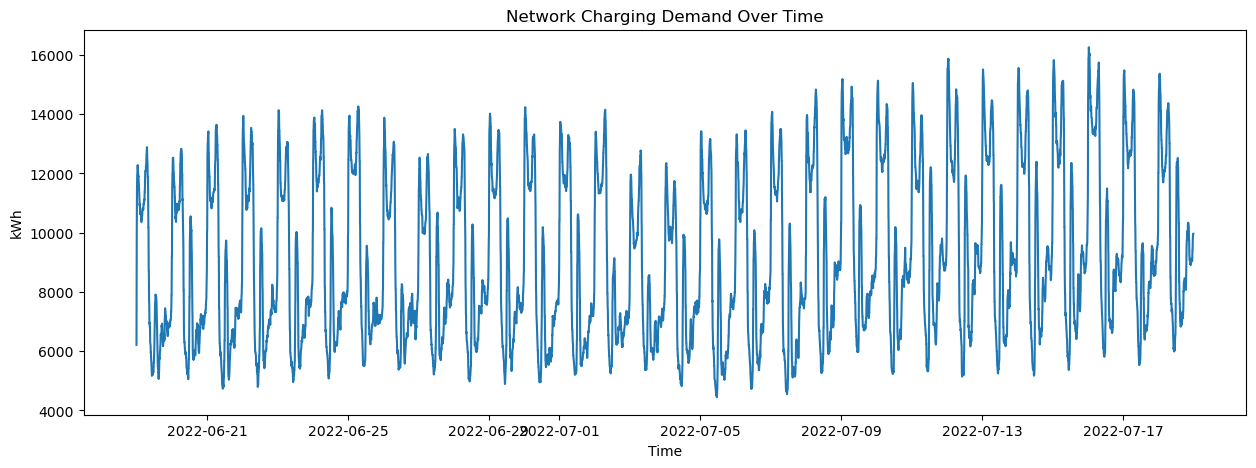

In [35]:
# Network Demand Over Time

network_volume = (
    urbanev_master
    .groupby('timestamp')['volume']
    .sum()
)

plt.figure(figsize=(15,5))
plt.plot(network_volume)

plt.title('Network Charging Demand Over Time')
plt.ylabel('kWh')
plt.xlabel('Time')
plt.show()

In [36]:
# Intraday Charging Behavior

# Average Demand by Hour

urbanev_master['hour'] = (
    urbanev_master['timestamp']
    .dt.hour
)

hourly_demand = (
    urbanev_master
    .groupby('hour')['volume']
    .mean()
)

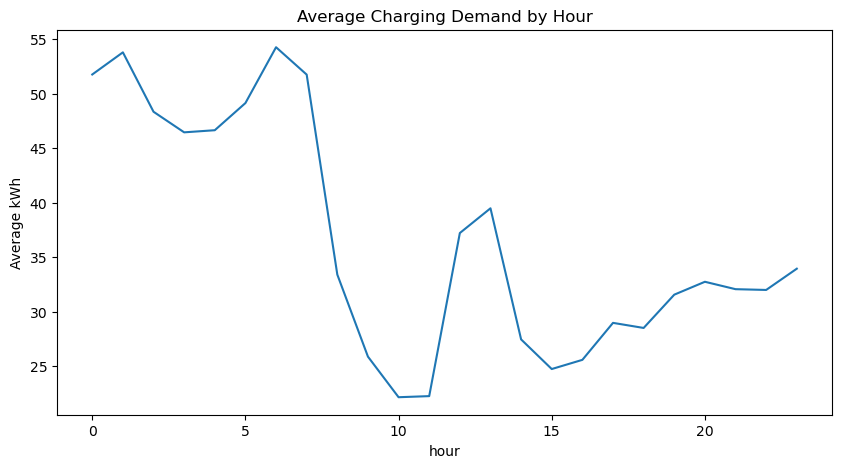

In [37]:
plt.figure(figsize=(10,5))
hourly_demand.plot()

plt.title('Average Charging Demand by Hour')
plt.ylabel('Average kWh')
plt.show()

In [38]:
# Weekday vs Weekend

# Create Weekend Flag

urbanev_master['weekday'] = (
    urbanev_master['timestamp']
    .dt.day_name()
)

urbanev_master['weekend'] = (
    urbanev_master['timestamp']
    .dt.dayofweek >= 5
)

In [39]:
# Compare Demand

weekend_analysis = (
    urbanev_master
    .groupby('weekend')
    ['volume']
    .mean()
)

display(weekend_analysis)

weekend
False    36.498925
True     37.097333
Name: volume, dtype: float64

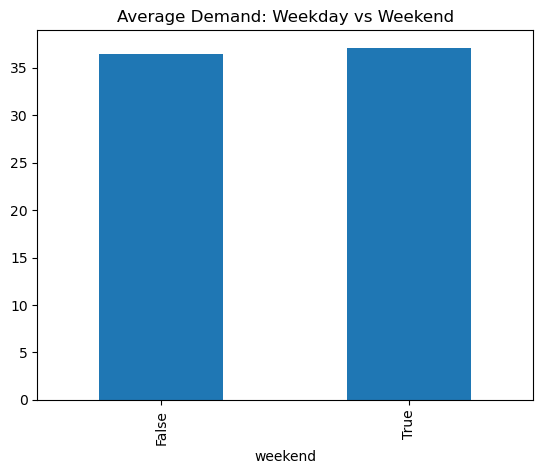

In [40]:
weekend_analysis.plot(
    kind='bar'
)

plt.title(
    'Average Demand: Weekday vs Weekend'
)

plt.show()

# Weekend charging demand remains comparable to weekday demand, indicating that public charging behavior differs substantially from workplace charging patterns.

In [41]:
# Occupancy Analysis

# Average Occupancy by Hour

hourly_occ = (
    urbanev_master
    .groupby('hour')
    ['occupancy_density']
    .mean()
)

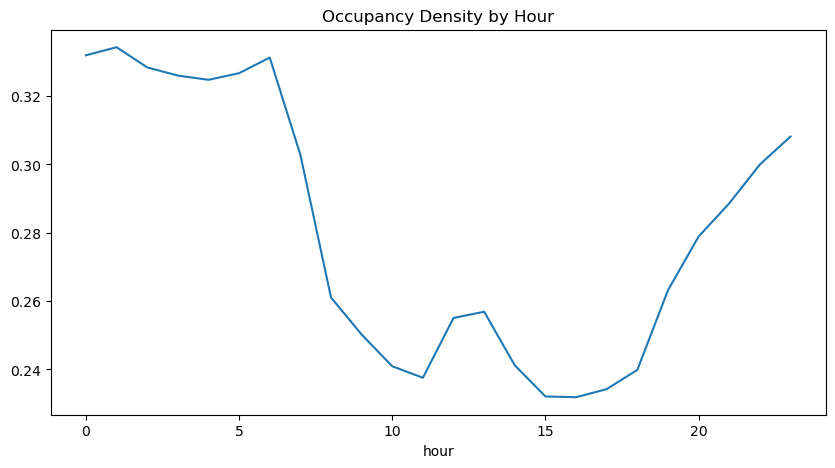

In [42]:
plt.figure(figsize=(10,5))
hourly_occ.plot()

plt.title(
    'Occupancy Density by Hour'
)

plt.show()

In [43]:
# Peak / Shoulder / Off-Peak Analysis

# Define Periods

def tariff_period(hour):

    if 17 <= hour <= 21:
        return 'Peak'

    elif 8 <= hour < 17:
        return 'Shoulder'

    else:
        return 'Off-Peak'

In [44]:
urbanev_master['tariff_period'] = (
    urbanev_master['hour']
    .apply(tariff_period)
)

In [45]:
# Compare Demand

period_analysis = (
    urbanev_master
    .groupby('tariff_period')
    .agg(
        avg_volume=('volume','mean'),
        avg_occ=('occupancy_density','mean'),
        avg_revenue=('revenue','mean')
    )
)

display(period_analysis)

,avg_volume,avg_occ,avg_revenue
tariff_period,,,
Off-Peak,46.822281,0.321437,33.292206
Peak,30.774596,0.260950,28.278155
Shoulder,28.687440,0.245205,27.291700


In [49]:
# Demand KPIs

network_hourly = (
    urbanev_master
    .groupby('hour')['volume']
    .mean()
)

peak_hour = network_hourly.idxmax()
peak_demand = network_hourly.max()

offpeak_hour = network_hourly.idxmin()
offpeak_demand = network_hourly.min()

print("Peak Hour:", peak_hour)
print("Peak Demand:", peak_demand)

print("Offpeak Hour:", offpeak_hour)
print("Offpeak Demand:", offpeak_demand)

print(
    "Peak/Offpeak Ratio:",
    peak_demand/offpeak_demand
)

Peak Hour: 6
Peak Demand: 54.28011571575208
Offpeak Hour: 10
Offpeak Demand: 22.15176142098601
Peak/Offpeak Ratio: 2.4503746986155464


# Peak-hour charging demand is 2.45× higher than off-peak demand.

In [46]:
# Geography Analysis

cbd_analysis = (
    urbanev_master
    .groupby('CBD')
    .agg(
        avg_volume=('volume','mean'),
        avg_occ=('occupancy_density','mean'),
        avg_revenue=('revenue','mean')
    )
)

display(cbd_analysis)

,avg_volume,avg_occ,avg_revenue
CBD,,,
0,43.222607,0.292872,34.574356
1,17.151522,0.242580,16.340442


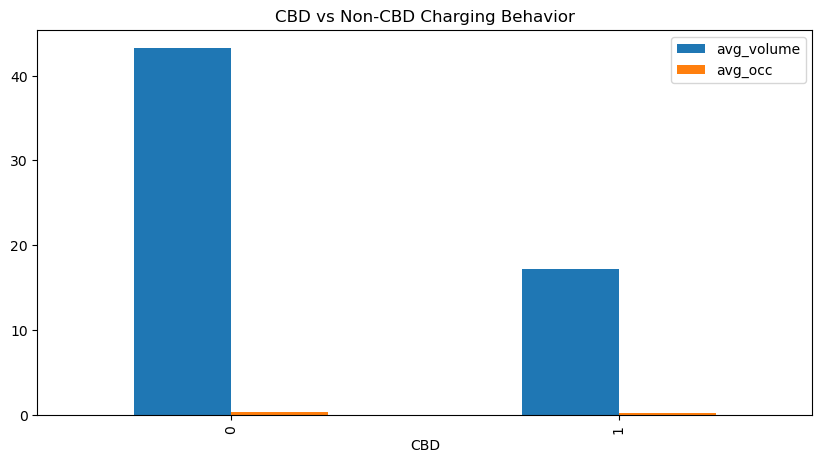

In [47]:
cbd_analysis[
    ['avg_volume','avg_occ']
].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'CBD vs Non-CBD Charging Behavior'
)

plt.show()

In [53]:
cbd_analysis = (
    urbanev_master
    .groupby('CBD')
    .agg({
        'volume':'mean',
        'occupancy_density':'mean',
        'revenue':'mean'
    })
)

display(cbd_analysis)

,volume,occupancy_density,revenue
CBD,,,
0,43.222607,0.292872,34.574356
1,17.151522,0.242580,16.340442


In [54]:
cbd_analysis.loc[1] / cbd_analysis.loc[0]

volume               0.396818
occupancy_density    0.828280
revenue              0.472617
dtype: float64

# Contrary to expectations, CBD charging stations exhibit 60% lower charging demand, 17% lower congestion, and 53% lower revenue than non-CBD locations.

In [48]:
# Dynamic Pricing Evaluation

# Compare Stations

pricing_analysis = (
    urbanev_master
    .groupby('dynamic_pricing')
    .agg(
        avg_volume=('volume','mean'),
        avg_occ=('occupancy_density','mean'),
        avg_revenue=('revenue','mean')
    )
)

display(pricing_analysis)

,avg_volume,avg_occ,avg_revenue
dynamic_pricing,,,
0,13.139973,0.258284,12.217223
1,115.140030,0.353461,89.264753


# Charging prices vary significantly across stations and periods, providing a natural foundation for dynamic tariff optimization.

In [55]:
pricing_analysis = (
    urbanev_master
    .groupby('dynamic_pricing')
    .agg({
        'volume':'mean',
        'occupancy_density':'mean',
        'revenue':'mean'
    })
)

display(pricing_analysis)

,volume,occupancy_density,revenue
dynamic_pricing,,,
0,13.139973,0.258284,12.217223
1,115.140030,0.353461,89.264753


# Stations operating under dynamic pricing generate 8.8× more charging demand and 7.3× higher revenue, despite experiencing only 37% higher occupancy density.

In [56]:
capacity_util = (
    urbanev_master
    .groupby('station_id')
    ['utilization_rate']
    .mean()
)

print(capacity_util.describe())

count    247.000000
mean       0.280248
std        0.133285
min        0.061750
25%        0.174921
50%        0.274231
75%        0.361176
max        0.760269
Name: utilization_rate, dtype: float64


# Average network utilization is 28.0%, indicating substantial spare charging capacity at the network level.
# While the overall network is underutilized, a small number of stations experience significantly higher congestion.